# Collision Data EDA

This notebook explores the raw Toronto collision dataset used in the project.  
The focus is on time patterns, mode involvement, location concentration, and a few summary visuals 

In [54]:
# Imports, paths, and plotting style
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap, LogNorm

sns.set_theme(style="white", context="talk")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 320
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.facecolor"] = "#ffffff"
plt.rcParams["figure.facecolor"] = "#ffffff"
plt.rcParams["grid.color"] = "#e5e7eb"
plt.rcParams["grid.alpha"] = 0.65
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True

def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start] + list(start.parents):
        if (p / "data").exists() and (p / "results").exists():
            return p
    return start

NOTEBOOK_DIR = Path.cwd()
REPO_DIR = find_repo_root(NOTEBOOK_DIR)
RAW_DIR = REPO_DIR / "data" / "data_raw"
FIG_DIR = REPO_DIR / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

FILE_PATH = RAW_DIR / "Traffic_Collisions 2023-2025.xlsx"

print("Repo root:", REPO_DIR)
print("Raw file:", FILE_PATH)
print("Figure folder:", FIG_DIR)

def save_and_show(fig, fig_name: str):
    fig.patch.set_facecolor("white")
    out = FIG_DIR / f"{fig_name}.png"
    fig.savefig(out, bbox_inches="tight", facecolor="white")
    print("Saved:", out)
    plt.show()
    plt.close(fig)

def count_fmt(x, pos):
    return f"{int(x):,}"

count_formatter = FuncFormatter(count_fmt)

# Project palette
GREEN = "#22c55e"
LIGHT_GREEN = "#bbf7d0"
YELLOW = "#facc15"
ORANGE = "#fb923c"
RED = "#ef4444"
DARK_RED = "#b91c1c"
BLUE = "#2563eb"
TEAL = "#0f766e"
SLATE = "#475569"

TRAFFIC_CMAP = LinearSegmentedColormap.from_list(
    "traffic_risk",
    ["#f0fdf4", "#86efac", "#facc15", "#fb923c", "#ef4444", "#b91c1c"]
)

DENSITY_CMAP = LinearSegmentedColormap.from_list(
    "traffic_density",
    ["#ecfdf5", "#86efac", "#facc15", "#fb923c", "#ef4444", "#b91c1c"]
)

Repo root: /Users/singye/Desktop/toronto-prediction-collision
Raw file: /Users/singye/Desktop/toronto-prediction-collision/data/data_raw/Traffic_Collisions 2023-2025.xlsx
Figure folder: /Users/singye/Desktop/toronto-prediction-collision/results/figures


## Load and prepare the raw collision file

In [55]:
df = pd.read_excel(FILE_PATH, engine="openpyxl")
print("Shape:", df.shape)
print("Columns:", len(df.columns))
display(df.head())

Shape: (205227, 23)
Columns: 23


,OBJECTID,EVENT_UNIQUE_ID,OCC_DATE,OCC_MONTH,OCC_DOW,OCC_YEAR,OCC_HOUR,DIVISION,FATALITIES,INJURY_COLLISIONS,...,NEIGHBOURHOOD_158,LONG_WGS84,LAT_WGS84,AUTOMOBILE,MOTORCYCLE,PASSENGER,BICYCLE,PEDESTRIAN,x,y
0,585499,GO-20238050463,2023-01-01 05:00:00,January,Sunday,2023,0,D53,0,NO,...,Forest Hill South (101),-79.417003,43.698996,YES,NO,NO,NO,NO,-79.417003,43.698996
1,585500,GO-20238050544,2023-01-01 05:00:00,January,Sunday,2023,21,D43,0,NO,...,Morningside (135),-79.203018,43.791569,YES,NO,NO,NO,NO,-79.203018,43.791569
2,585501,GO-20238050541,2023-01-01 05:00:00,January,Sunday,2023,22,D52,0,NO,...,Kensington-Chinatown (78),-79.399163,43.656119,YES,NO,NO,NO,NO,-79.399163,43.656119
3,585502,GO-20238109784,2023-01-01 05:00:00,January,Sunday,2023,8,D31,0,NO,...,Black Creek (24),-79.508893,43.764550,YES,NO,NO,NO,NO,-79.508893,43.764550
4,585503,GO-20238109995,2023-01-01 05:00:00,January,Sunday,2023,14,D41,0,NO,...,Clairlea-Birchmount (120),-79.287687,43.713318,N/R,N/R,N/R,N/R,N/R,-79.287687,43.713318


In [56]:
# Build an EDA frame with cleaned date, hour, neighbourhood, and spatial fields
eda = df.copy()

if "OCC_DATE" in eda.columns:
    eda["OCC_DATE"] = pd.to_datetime(eda["OCC_DATE"], errors="coerce")

if "OCC_HOUR" in eda.columns:
    eda["OCC_HOUR"] = pd.to_numeric(eda["OCC_HOUR"], errors="coerce").clip(lower=0, upper=23)

if {"OCC_DATE", "OCC_HOUR"}.issubset(eda.columns):
    eda["occ_datetime"] = eda["OCC_DATE"].dt.floor("D") + pd.to_timedelta(eda["OCC_HOUR"].fillna(0), unit="h")
    eda["year"] = eda["occ_datetime"].dt.year
    eda["month"] = eda["occ_datetime"].dt.month
    eda["month_name"] = eda["occ_datetime"].dt.month_name()
    eda["month_period"] = eda["occ_datetime"].dt.to_period("M").dt.to_timestamp()
    eda["weekday"] = eda["occ_datetime"].dt.day_name()
    eda["hour"] = eda["occ_datetime"].dt.hour

if "DIVISION" in eda.columns:
    eda["division_clean"] = eda["DIVISION"].astype(str).str.strip()

if "NEIGHBOURHOOD_158" in eda.columns:
    eda["neighbourhood_clean"] = (
        eda["NEIGHBOURHOOD_158"]
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

if "HOOD_158" in eda.columns:
    eda["hood_code_clean"] = eda["HOOD_158"].astype(str).str.extract(r"(\d+)", expand=False)

for col in ["LONG_WGS84", "LAT_WGS84"]:
    if col in eda.columns:
        eda[col] = pd.to_numeric(eda[col], errors="coerce")

spatial = eda.copy()
if {"LONG_WGS84", "LAT_WGS84"}.issubset(spatial.columns):
    spatial = spatial.dropna(subset=["LONG_WGS84", "LAT_WGS84"]).copy()

summary = {
    "records": len(eda),
    "columns": len(eda.columns),
    "duplicate_rows": int(df.duplicated().sum()),
    "start_date": eda["occ_datetime"].min() if "occ_datetime" in eda.columns else pd.NaT,
    "end_date": eda["occ_datetime"].max() if "occ_datetime" in eda.columns else pd.NaT,
    "divisions": int(eda["division_clean"].nunique()) if "division_clean" in eda.columns else np.nan,
    "neighbourhoods": int(eda["neighbourhood_clean"].nunique()) if "neighbourhood_clean" in eda.columns else np.nan,
}
display(pd.DataFrame(summary.items(), columns=["metric", "value"]))

,metric,value
0,records,205227
1,columns,33
2,duplicate_rows,0
3,start_date,2023-01-01 00:00:00
4,end_date,2025-12-31 23:00:00
5,divisions,17
6,neighbourhoods,159


## Data quality snapshot
A quick view of missingness helps show which fields are complete enough for analysis and which ones need caution in later modeling steps.

In [57]:
missing = (
    pd.DataFrame({
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean().values * 100).round(1),
    })
    .sort_values(["missing_pct", "missing_count"], ascending=False)
    .reset_index(drop=True)
)

miss_plot = missing.query("missing_pct > 0").head(15).sort_values("missing_pct", ascending=True)
if len(miss_plot):
    fig, ax = plt.subplots(figsize=(11, 6))
    bars = ax.barh(
        miss_plot["column"],
        miss_plot["missing_pct"],
        color=sns.color_palette("Blues_r", n_colors=len(miss_plot))
    )
    ax.set_title("Top columns by missingness", pad=14)
    ax.set_xlabel("Missing values (%)")
    ax.set_ylabel("")
    ax.set_xlim(0, max(5, miss_plot["missing_pct"].max() * 1.1))

    for bar, val in zip(bars, miss_plot["missing_pct"]):
        ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2, f"{val:.1f}%", va="center", fontsize=10)

    sns.despine(left=True, bottom=True)
    save_and_show(fig, "collision_missingness_top15")
else:
    print("No missing values to plot.")

display(missing.head(15))

No missing values to plot.


,column,missing_count,missing_pct
0,OBJECTID,0,0.0
1,EVENT_UNIQUE_ID,0,0.0
2,OCC_DATE,0,0.0
3,OCC_MONTH,0,0.0
4,OCC_DOW,0,0.0
5,OCC_YEAR,0,0.0
6,OCC_HOUR,0,0.0
7,DIVISION,0,0.0
8,FATALITIES,0,0.0
9,INJURY_COLLISIONS,0,0.0


## Time profile
These charts summarize when collisions occur across months, weekdays, and hours of the day.

Saved: /Users/singye/Desktop/toronto-prediction-collision/results/figures/collision_monthly_trend_styled.png


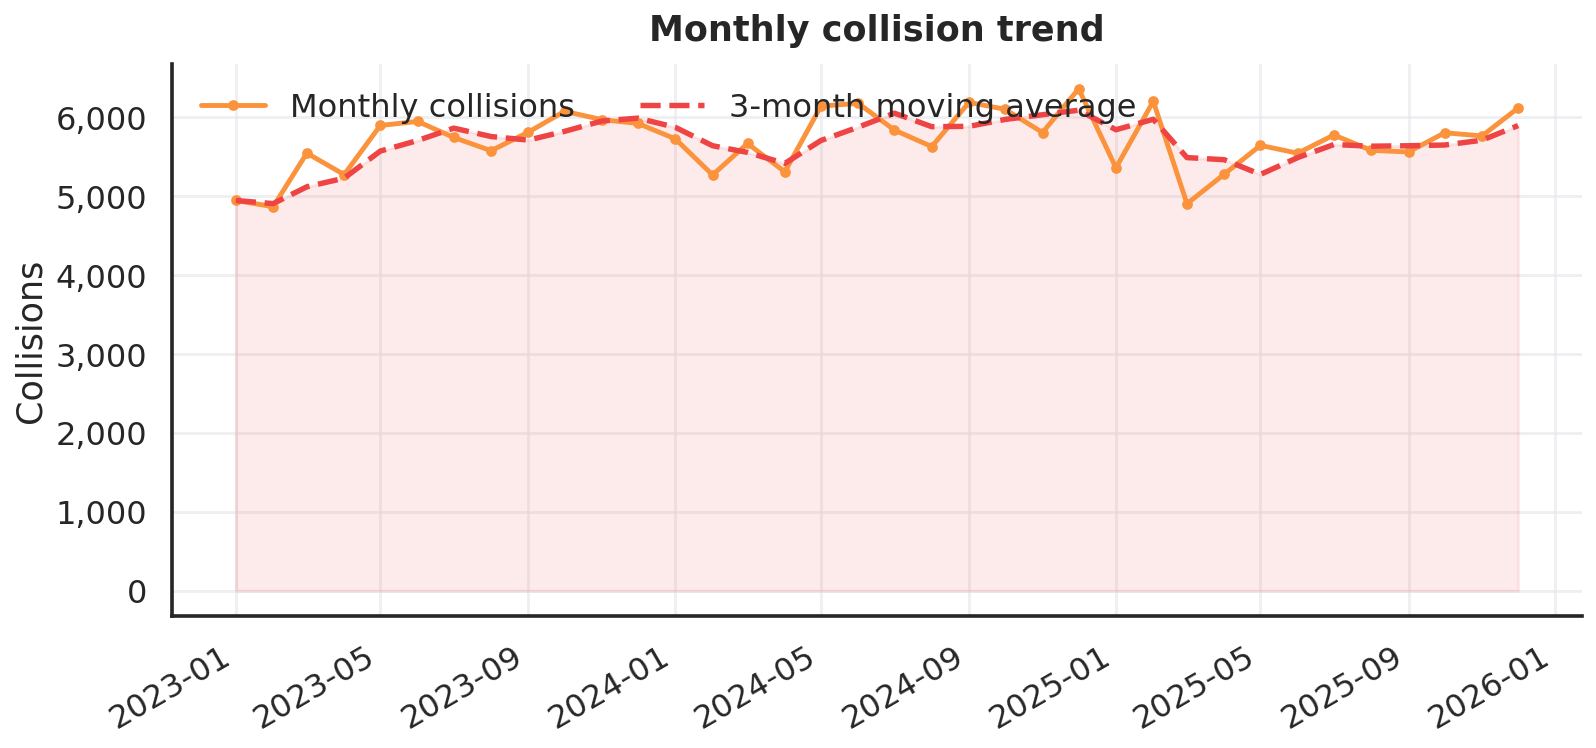

In [59]:
if "month_period" in eda.columns:
    monthly = (
        eda.groupby("month_period")
        .size()
        .rename("collisions")
        .reset_index()
    )
    monthly["month_date"] = pd.to_datetime(monthly["month_period"])
    monthly["rolling_3m"] = monthly["collisions"].rolling(3, min_periods=1).mean()

    fig, ax = plt.subplots(figsize=(13, 5.8))
    ax.plot(
        monthly["month_date"],
        monthly["collisions"],
        color=ORANGE,
        linewidth=2.5,
        marker="o",
        markersize=4.5,
        label="Monthly collisions",
    )
    ax.plot(
        monthly["month_date"],
        monthly["rolling_3m"],
        color=RED,
        linewidth=2.8,
        linestyle="--",
        label="3-month moving average",
    )
    ax.fill_between(
        monthly["month_date"],
        monthly["rolling_3m"],
        color=RED,
        alpha=0.10,
    )
    ax.set_title("Monthly collision trend", pad=12)
    ax.set_xlabel("")
    ax.set_ylabel("Collisions")
    ax.yaxis.set_major_formatter(count_formatter)
    ax.legend(frameon=False, ncol=2, loc="upper left")
    ax.spines[["top", "right"]].set_visible(False)
    fig.autofmt_xdate()
    save_and_show(fig, "collision_monthly_trend_styled")
else:
    print("Month field is not available.")

Saved: /Users/singye/Desktop/toronto-prediction-collision/results/figures/collision_weekday_hour_styled.png


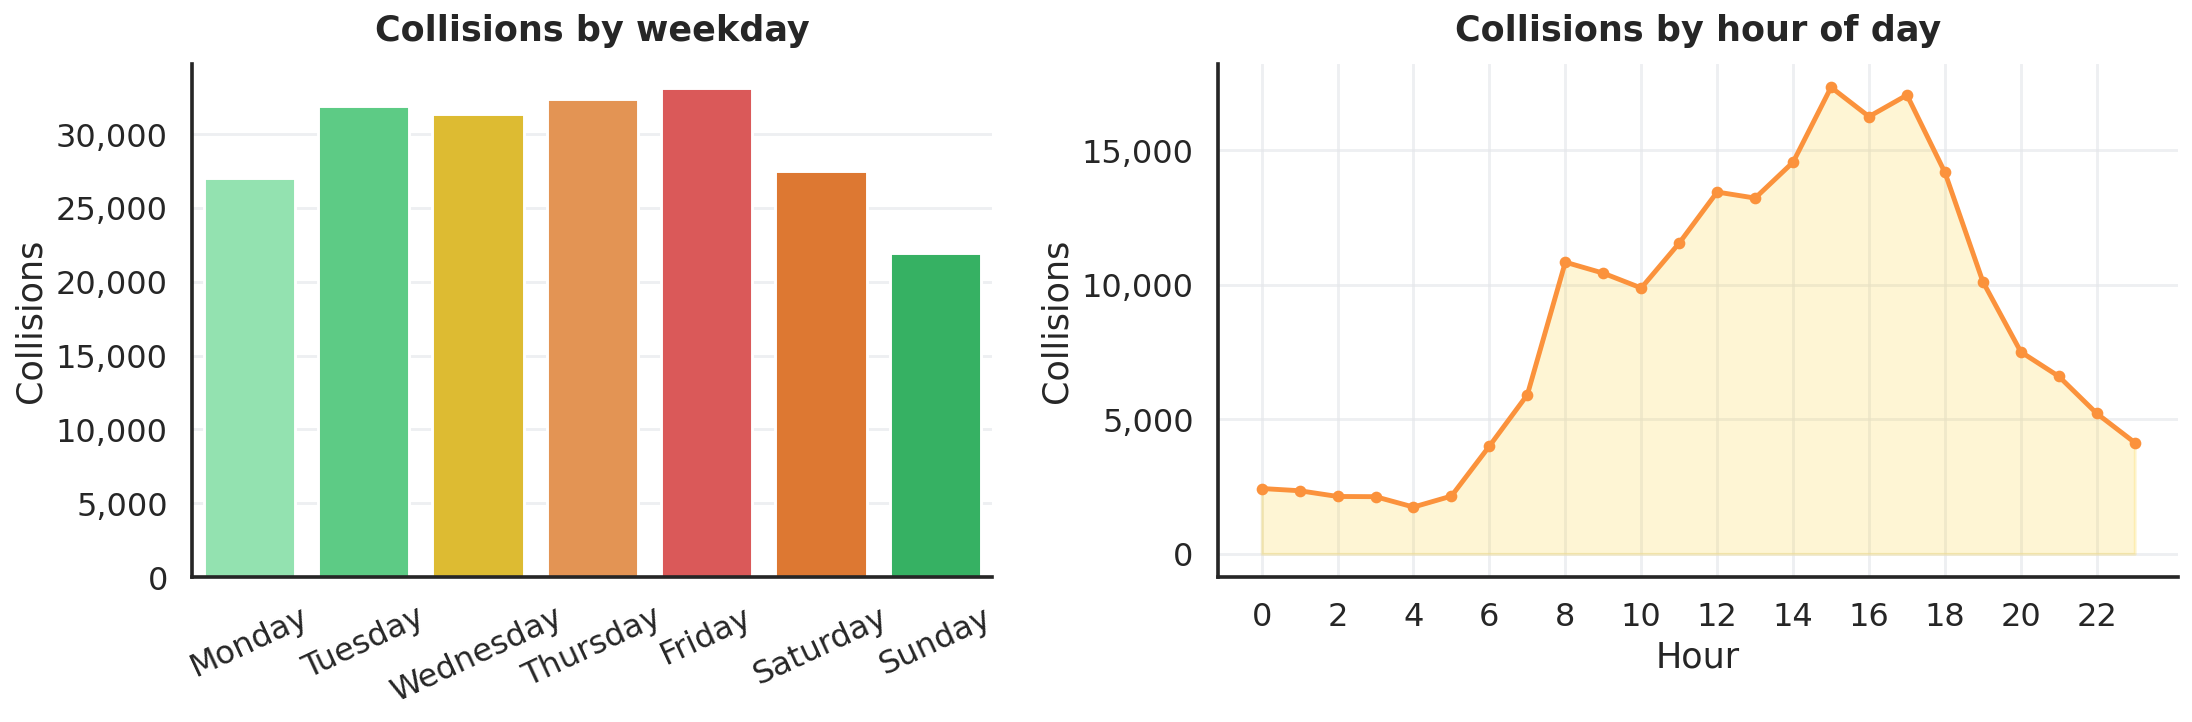

In [60]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

if {"weekday", "hour"}.issubset(eda.columns):
    day_counts = (
        eda["weekday"].value_counts()
        .reindex(weekday_order)
        .fillna(0)
        .astype(int)
    )
    hour_counts = (
        eda["hour"].value_counts()
        .sort_index()
        .reindex(range(24), fill_value=0)
        .astype(int)
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={"width_ratios": [1, 1.2]})

    bar_colors = sns.color_palette(["#86efac", "#4ade80", "#facc15", "#fb923c", "#ef4444", "#f97316", "#22c55e"])
    sns.barplot(x=day_counts.index, y=day_counts.values, ax=axes[0], palette=bar_colors)
    axes[0].set_title("Collisions by weekday", pad=12)
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Collisions")
    axes[0].yaxis.set_major_formatter(count_formatter)
    axes[0].tick_params(axis="x", rotation=25)

    axes[1].plot(hour_counts.index, hour_counts.values, color=ORANGE, linewidth=2.5, marker="o", markersize=5)
    axes[1].fill_between(hour_counts.index, hour_counts.values, color=YELLOW, alpha=0.18)
    axes[1].set_title("Collisions by hour of day", pad=12)
    axes[1].set_xlabel("Hour")
    axes[1].set_ylabel("Collisions")
    axes[1].set_xticks(range(0, 24, 2))
    axes[1].yaxis.set_major_formatter(count_formatter)

    for ax in axes:
        sns.despine(ax=ax)

    fig.tight_layout()
    save_and_show(fig, "collision_weekday_hour_styled")
else:
    print("Weekday or hour fields are not available.")

Saved: /Users/singye/Desktop/toronto-prediction-collision/results/figures/collision_weekday_hour_heatmap_styled.png


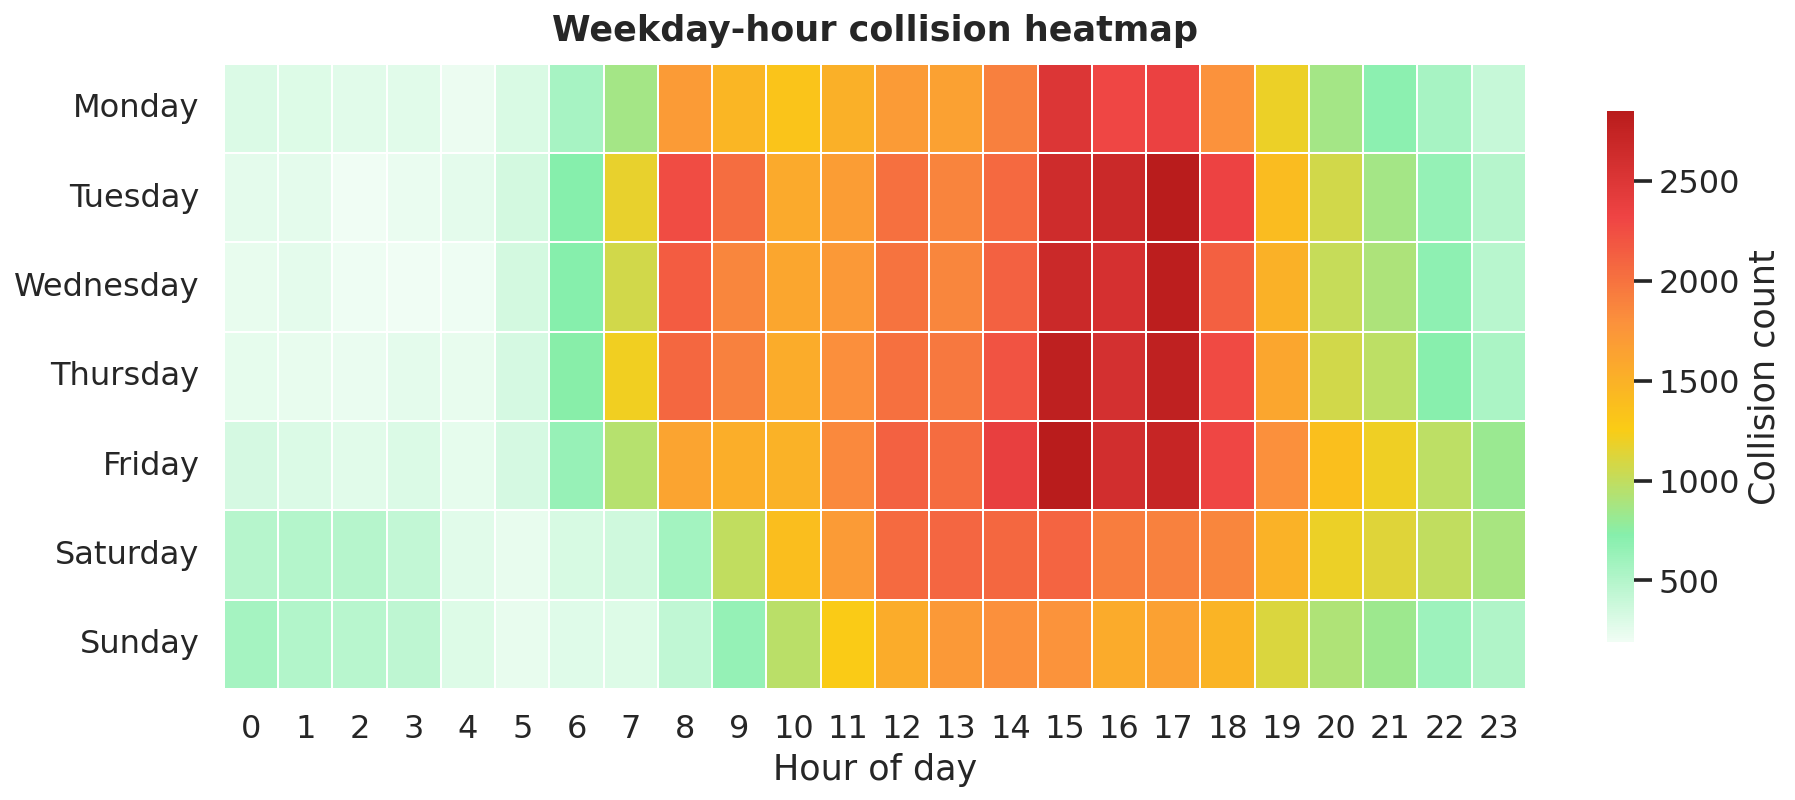

In [61]:
if {"weekday", "hour"}.issubset(eda.columns):
    heat = (
        eda.groupby(["weekday", "hour"]).size()
        .unstack(fill_value=0)
        .reindex(index=weekday_order, columns=range(24), fill_value=0)
    )

    fig, ax = plt.subplots(figsize=(15, 5.8))
    sns.heatmap(
        heat,
        ax=ax,
        cmap=TRAFFIC_CMAP,
        linewidths=0.25,
        linecolor="white",
        cbar_kws={"label": "Collision count", "shrink": 0.85},
    )
    ax.set_title("Weekday-hour collision heatmap", pad=12)
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("")
    ax.tick_params(axis="y", rotation=0)
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    save_and_show(fig, "collision_weekday_hour_heatmap_styled")
else:
    print("Heatmap fields are not available.")

## Location and involvement patterns
These views highlight where collisions cluster and which travel modes appear most often in the records.

Saved: /Users/singye/Desktop/toronto-prediction-collision/results/figures/collision_top_divisions_neighbourhoods_styled.png


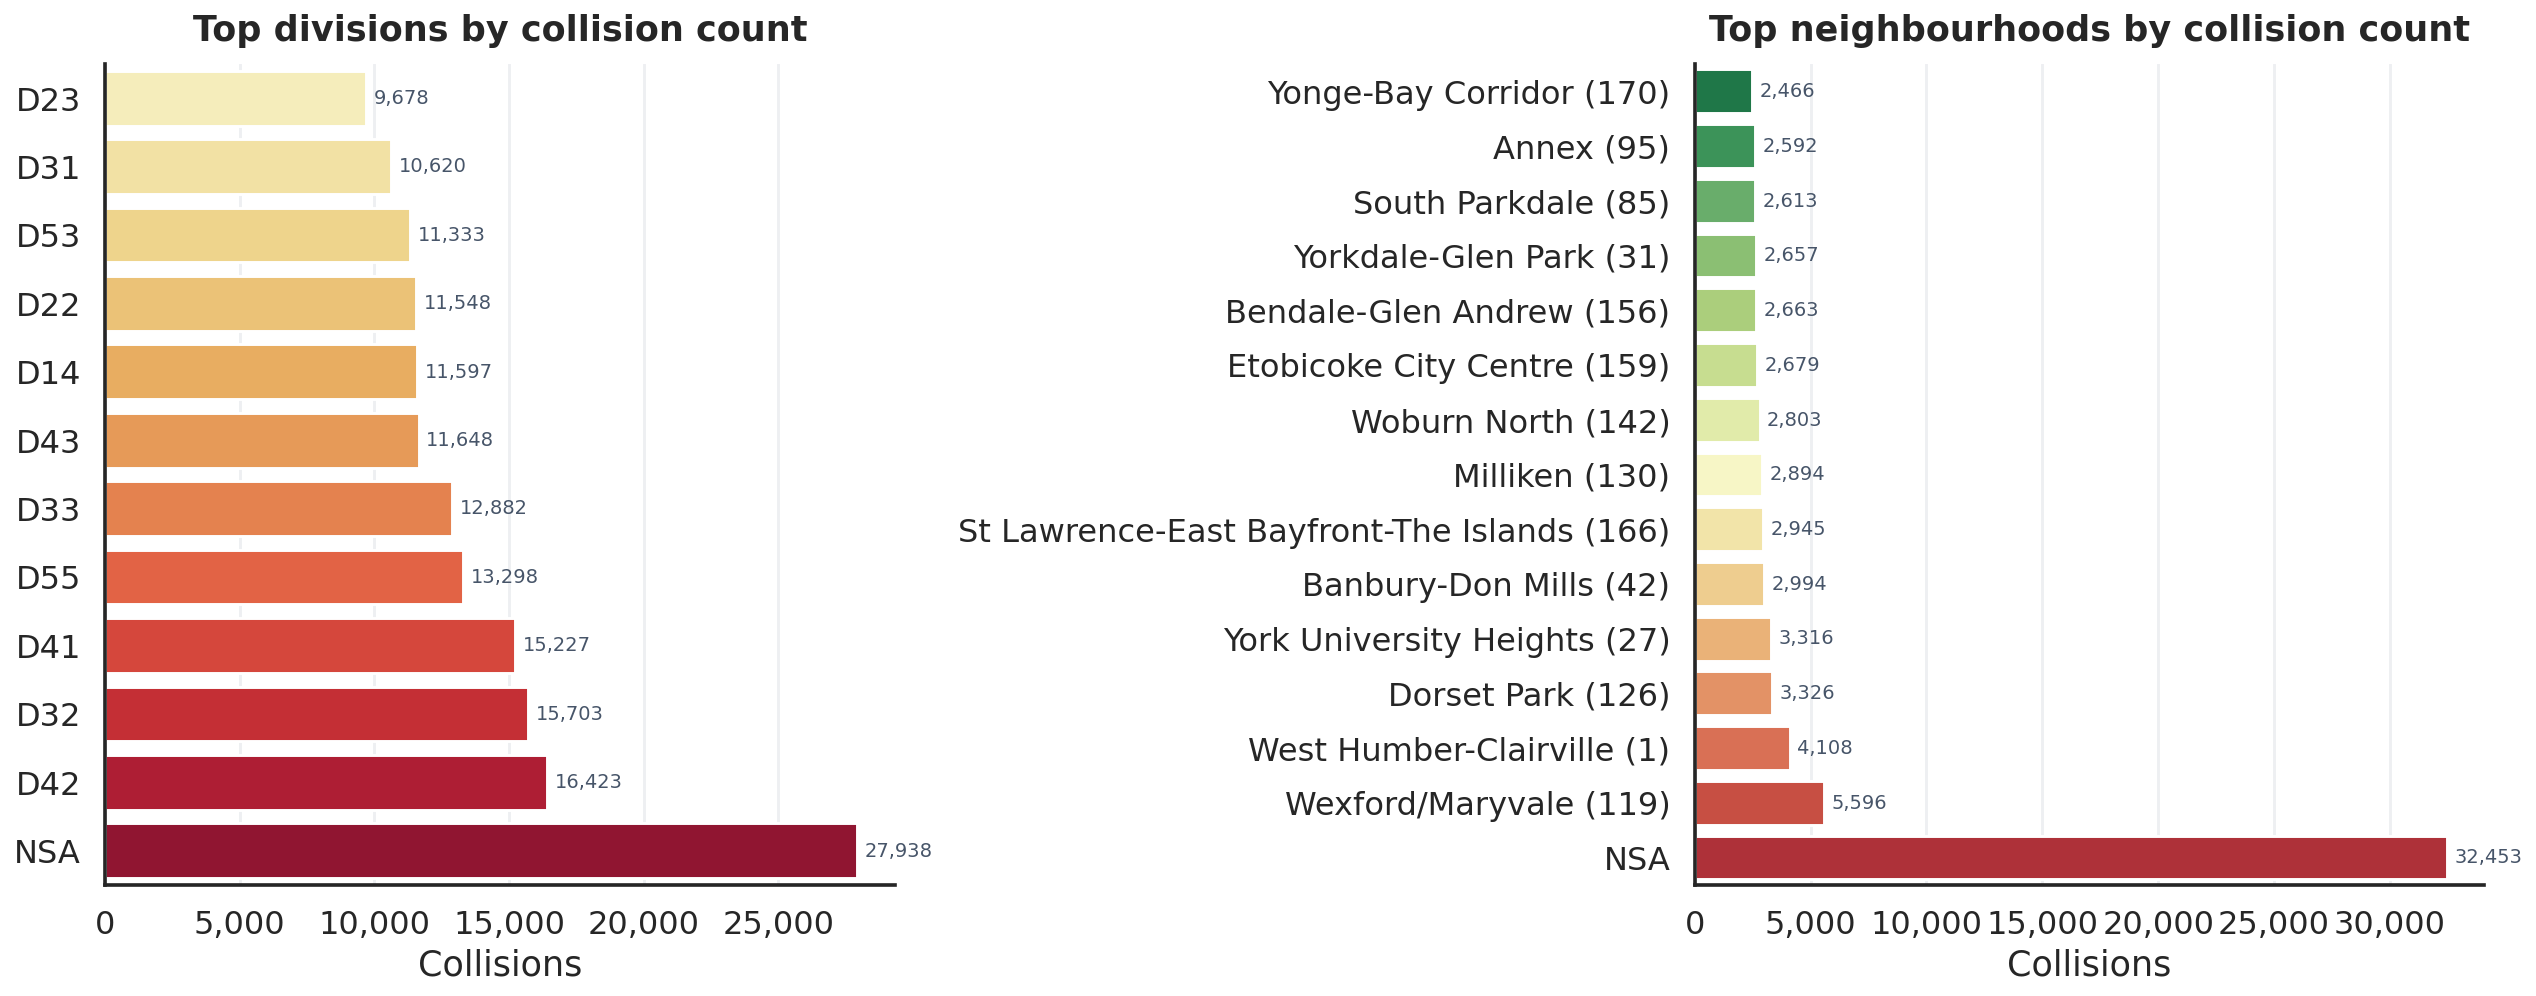

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)

if "division_clean" in eda.columns:
    top_div = eda["division_clean"].value_counts().head(12).sort_values()
    sns.barplot(x=top_div.values, y=top_div.index, ax=axes[0], palette=sns.color_palette("YlOrRd", n_colors=len(top_div)))
    axes[0].set_title("Top divisions by collision count", pad=12)
    axes[0].set_xlabel("Collisions")
    axes[0].set_ylabel("")
    axes[0].xaxis.set_major_formatter(count_formatter)
    for y, v in enumerate(top_div.values):
        axes[0].text(v + max(top_div.values) * 0.01, y, f"{v:,}", va="center", fontsize=10, color=SLATE)
else:
    axes[0].text(0.5, 0.5, "Division field not available", ha="center", va="center")
    axes[0].axis("off")

if "neighbourhood_clean" in eda.columns:
    top_hood = eda["neighbourhood_clean"].value_counts().head(15).sort_values()
    sns.barplot(x=top_hood.values, y=top_hood.index, ax=axes[1], palette=sns.color_palette("RdYlGn_r", n_colors=len(top_hood)))
    axes[1].set_title("Top neighbourhoods by collision count", pad=12)
    axes[1].set_xlabel("Collisions")
    axes[1].set_ylabel("")
    axes[1].xaxis.set_major_formatter(count_formatter)
    for y, v in enumerate(top_hood.values):
        axes[1].text(v + max(top_hood.values) * 0.01, y, f"{v:,}", va="center", fontsize=10, color=SLATE)
else:
    axes[1].text(0.5, 0.5, "Neighbourhood field not available", ha="center", va="center")
    axes[1].axis("off")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

save_and_show(fig, "collision_top_divisions_neighbourhoods_styled")

Saved: /Users/singye/Desktop/toronto-prediction-collision/results/figures/collision_mode_involvement_styled.png


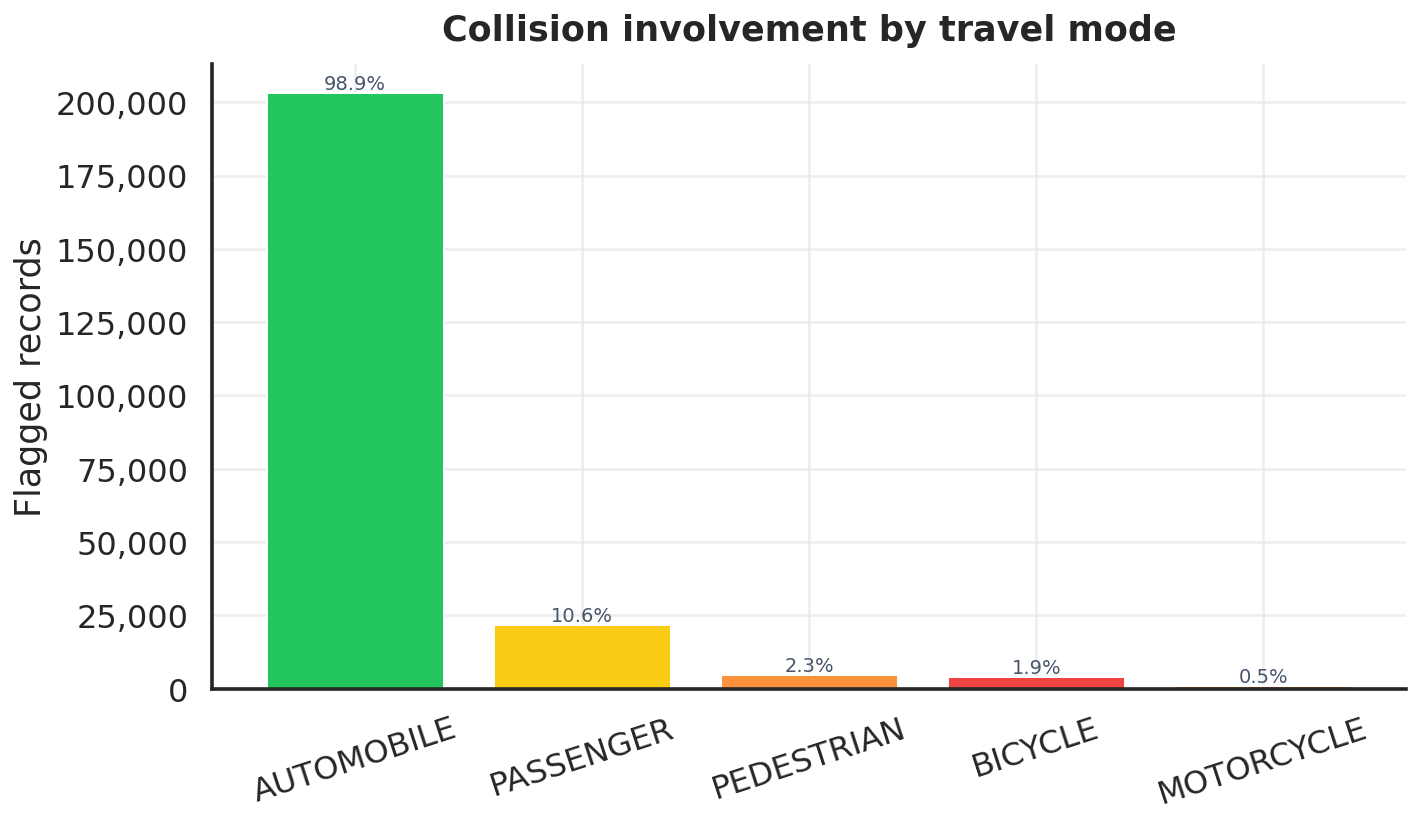

,flagged_records,share_pct_of_all_records
AUTOMOBILE,203014,98.9
PASSENGER,21672,10.6
PEDESTRIAN,4748,2.3
BICYCLE,3869,1.9
MOTORCYCLE,958,0.5


In [63]:
mode_cols = [c for c in ["AUTOMOBILE", "PASSENGER", "PEDESTRIAN", "BICYCLE", "MOTORCYCLE"] if c in eda.columns]

if mode_cols:
    mode_summary = {}
    for c in mode_cols:
        s = eda[c].astype(str).str.strip().str.upper()
        mode_summary[c] = int(s.isin(["YES", "Y", "1", "TRUE"]).sum())

    mode_summary = pd.Series(mode_summary).sort_values(ascending=False)
    mode_share = (mode_summary / len(eda) * 100).round(1)

    fig, ax = plt.subplots(figsize=(11, 5.8))
    bar_colors = [GREEN, YELLOW, ORANGE, RED, "#f97316"][:len(mode_summary)]
    bars = ax.bar(
        mode_summary.index,
        mode_summary.values,
        color=bar_colors,
        width=0.78,
        edgecolor="white",
        linewidth=1.0,
    )
    ax.set_title("Collision involvement by travel mode", pad=12)
    ax.set_xlabel("")
    ax.set_ylabel("Flagged records")
    ax.yaxis.set_major_formatter(count_formatter)
    ax.tick_params(axis="x", rotation=18)

    for bar, count, pct in zip(bars, mode_summary.values, mode_share.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            color=SLATE,
        )

    ax.spines[["top", "right"]].set_visible(False)
    save_and_show(fig, "collision_mode_involvement_styled")
    display(pd.DataFrame({"flagged_records": mode_summary, "share_pct_of_all_records": mode_share}))
else:
    print("Mode involvement columns are not available.")

Saved: /Users/singye/Desktop/toronto-prediction-collision/results/figures/collision_spatial_density_styled.png


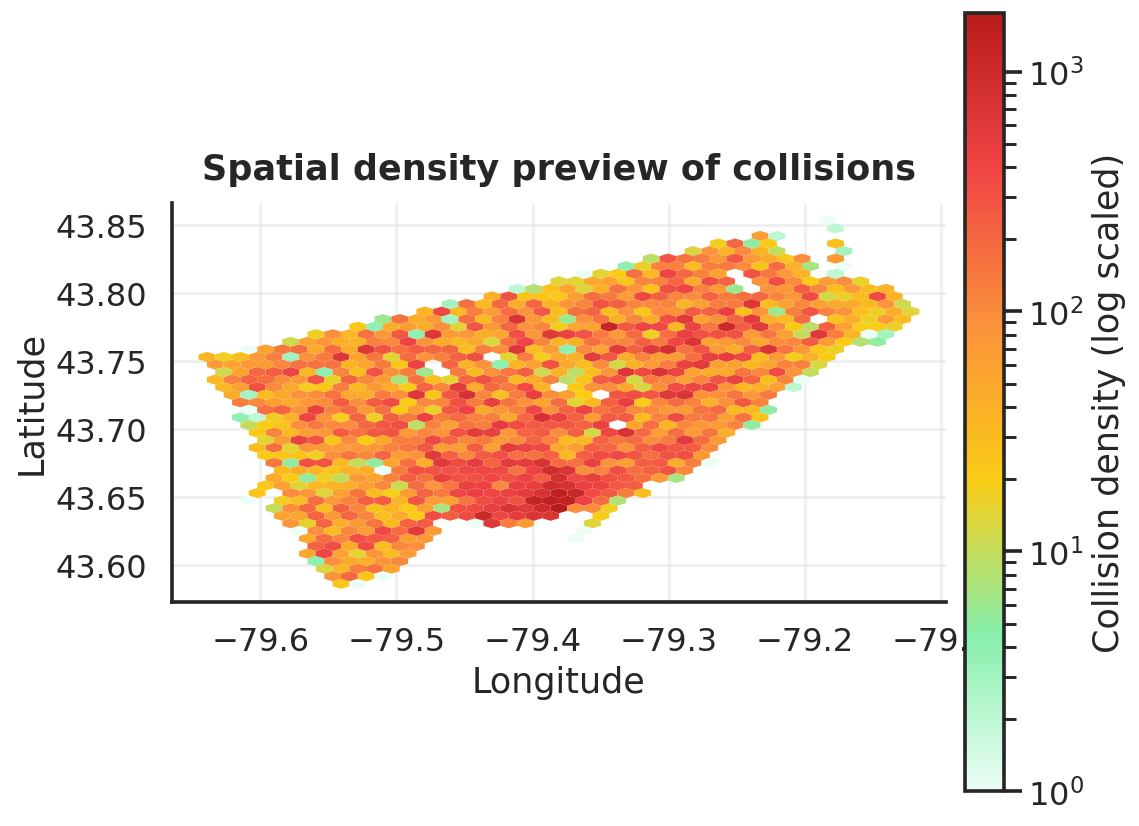

In [64]:
spatial = df.copy()
if {"LONG_WGS84", "LAT_WGS84"}.issubset(spatial.columns):
    spatial = spatial.dropna(subset=["LONG_WGS84", "LAT_WGS84"])
    spatial = spatial[
        spatial["LONG_WGS84"].between(-79.70, -79.00)
        & spatial["LAT_WGS84"].between(43.55, 43.95)
    ]

if {"LONG_WGS84", "LAT_WGS84"}.issubset(spatial.columns) and len(spatial):
    fig, ax = plt.subplots(figsize=(8.6, 8.2))
    hb = ax.hexbin(
        spatial["LONG_WGS84"],
        spatial["LAT_WGS84"],
        gridsize=42,
        cmap=DENSITY_CMAP,
        mincnt=1,
        linewidths=0,
        norm=LogNorm(),
    )
    cb = fig.colorbar(hb, ax=ax, shrink=0.88, pad=0.02)
    cb.set_label("Collision density (log scaled)")
    ax.set_title("Spatial density preview of collisions", pad=12)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal", adjustable="box")
    ax.spines[["top", "right"]].set_visible(False)
    save_and_show(fig, "collision_spatial_density_styled")
else:
    print("Spatial coordinates are not available.")

## Compact summary table
This final table provides a small set of values 

In [65]:
report_stats = {
    "records": len(eda),
    "duplicate_rows": int(df.duplicated().sum()),
    "date_start": eda["occ_datetime"].min() if "occ_datetime" in eda.columns else pd.NaT,
    "date_end": eda["occ_datetime"].max() if "occ_datetime" in eda.columns else pd.NaT,
    "divisions": int(eda["division_clean"].nunique()) if "division_clean" in eda.columns else np.nan,
    "neighbourhoods": int(eda["neighbourhood_clean"].nunique()) if "neighbourhood_clean" in eda.columns else np.nan,
    "rows_with_coordinates": len(spatial) if {"LONG_WGS84", "LAT_WGS84"}.issubset(spatial.columns) else np.nan,
}

report_stats_df = pd.DataFrame(report_stats.items(), columns=["metric", "value"])
display(report_stats_df)

,metric,value
0,records,205227
1,duplicate_rows,0
2,date_start,2023-01-01 00:00:00
3,date_end,2025-12-31 23:00:00
4,divisions,17
5,neighbourhoods,159
6,rows_with_coordinates,172774
